🚀 WebScanPro ML - Server Response Analysis
Dataset loaded: 28 records
Collection date: 2025-10-15

📊 Dataset Overview:
Shape: (28, 15)
Columns: ['url', 'method', 'param_name', 'input_type', 'default_value', 'form_action', 'input_value', 'label', 'is_malicious', 'response_status', 'response_time', 'html_content_length', 'error_message_flag', 'response_body_path', 'timestamp']

📋 Data Types:
url                     object
method                  object
param_name              object
input_type              object
default_value           object
form_action             object
input_value             object
label                   object
is_malicious             int64
response_status          int64
response_time          float64
html_content_length      int64
error_message_flag       int64
response_body_path      object
timestamp               object
dtype: object

🏷️ Label Distribution:
label
injection    15
safe         13
Name: count, dtype: int64


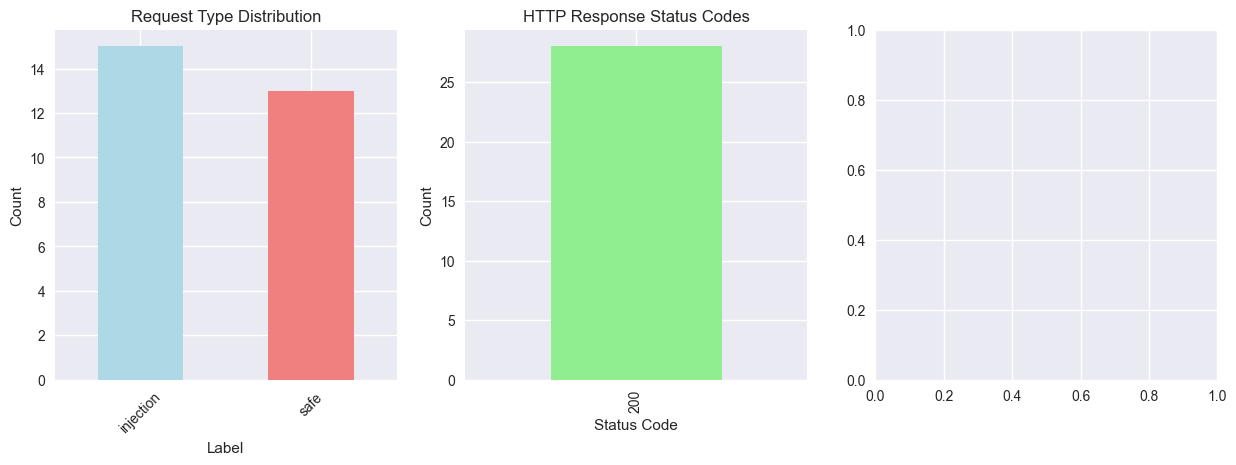

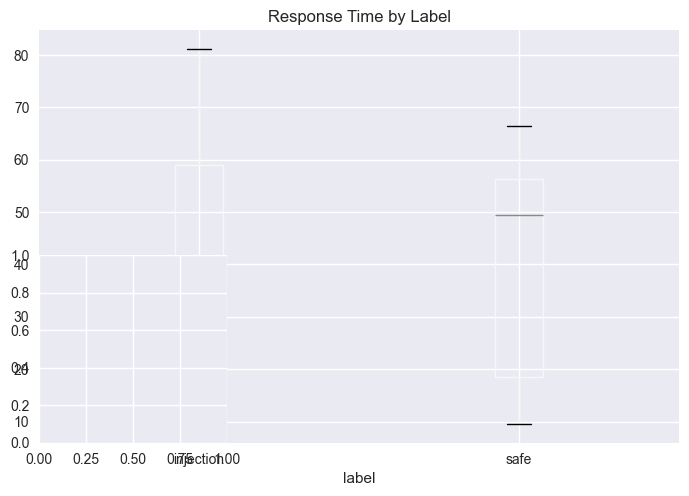

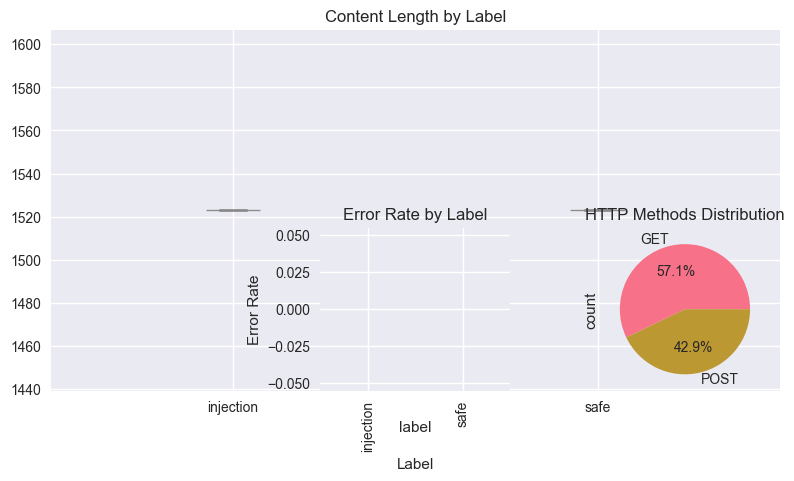


🔍 Detailed Analysis:

Response Time Statistics (ms):
                mean  median        std   min    max
label                                               
injection  35.184667   17.73  26.523155  9.72  81.13
safe       40.243077   49.50  20.853419  9.55  66.41

Content Length Statistics:
             mean  median  std   min   max
label                                     
injection  1523.0  1523.0  0.0  1523  1523
safe       1523.0  1523.0  0.0  1523  1523

Error Rate by Label:
           sum  count  error_rate
label                            
injection    0     15         0.0
safe         0     13         0.0

📈 Correlation Analysis:


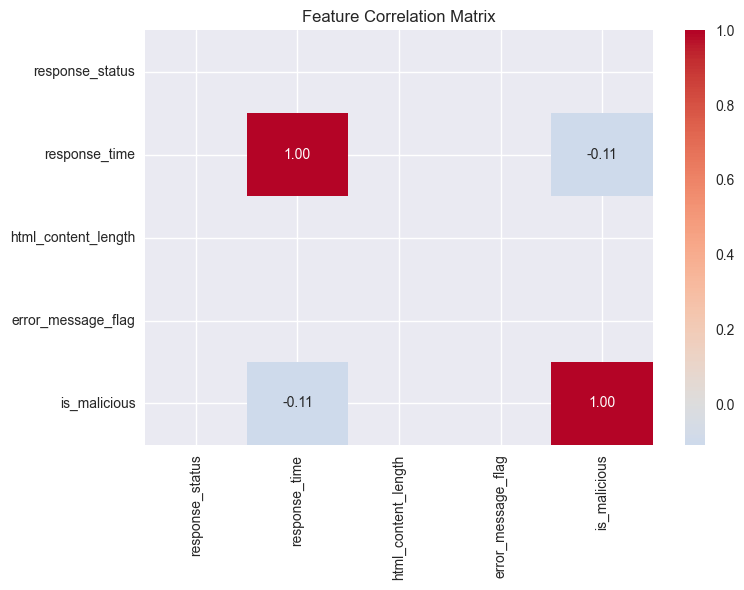


🌐 Top Targeted Endpoints:
url
/vulnerabilities/sqli_blind/    6
/vulnerabilities/exec/          6
/vulnerabilities/xss_s/         6
/vulnerabilities/sqli/          5
/vulnerabilities/xss_r/         5
Name: count, dtype: int64

🔑 Top Targeted Parameters:
param_name
id         11
txtName     6
ip          6
name        5
Name: count, dtype: int64

💡 Key Insights:
• Injection requests are 1.0x more likely to trigger errors
• Injection responses take 0.9x longer on average
• Dataset covers 5 endpoints with 4 parameters

✅ Analysis completed! Summary saved to: ../outputs/reports/response_analysis_summary.csv


In [4]:
# Server Response Collection Analysis
# This notebook analyzes the collected server response data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Setup
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the collected data - FIXED PATH
data_path = r'C:\Users\vishal\Desktop\WEBSCAN_PRO\data\raw_server_responses.csv'  # Added 'r' for raw string
# OR use forward slashes:
# data_path = 'C:/Users/vishal/Desktop/WEBSCAN_PRO/data/raw_server_responses.csv'

try:
    df = pd.read_csv(data_path)
    print("🚀 WebScanPro ML - Server Response Analysis")
    print("="*50)
    print(f"Dataset loaded: {len(df)} records")
    print(f"Collection date: {df['timestamp'].iloc[0][:10] if 'timestamp' in df.columns else 'Unknown'}")
    
except FileNotFoundError:
    print(f"❌ File not found: {data_path}")
    print("Please check:")
    print("1. The file exists at that location")
    print("2. You've run the data collection script first")
    print("3. The path is correct")
    # Create empty dataframe to avoid further errors
    df = pd.DataFrame()

except Exception as e:
    print(f"❌ Error loading file: {e}")
    df = pd.DataFrame()

# Only proceed if data loaded successfully
if not df.empty:
    # Basic Information
    print("\n📊 Dataset Overview:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Data Types
    print("\n📋 Data Types:")
    print(df.dtypes)

    # Label Distribution
    print("\n🏷️ Label Distribution:")
    label_counts = df['label'].value_counts()
    print(label_counts)

    # Visualization 1: Label Distribution
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    label_counts.plot(kind='bar', color=['lightblue', 'lightcoral'])
    plt.title('Request Type Distribution')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    # Response Status Distribution
    plt.subplot(2, 3, 2)
    status_counts = df['response_status'].value_counts().sort_index()
    status_counts.plot(kind='bar', color='lightgreen')
    plt.title('HTTP Response Status Codes')
    plt.xlabel('Status Code')
    plt.ylabel('Count')

    # Response Time Analysis
    plt.subplot(2, 3, 3)
    df.boxplot(column='response_time', by='label')
    plt.title('Response Time by Label')
    plt.suptitle('')  # Remove automatic title

    # Content Length Analysis
    plt.subplot(2, 3, 4)
    df.boxplot(column='html_content_length', by='label')
    plt.title('Content Length by Label')
    plt.suptitle('')  # Remove automatic title

    # Error Flag Analysis
    plt.subplot(2, 3, 5)
    error_by_label = df.groupby('label')['error_message_flag'].mean()
    error_by_label.plot(kind='bar', color=['lightblue', 'lightcoral'])
    plt.title('Error Rate by Label')
    plt.xlabel('Label')
    plt.ylabel('Error Rate')

    # Method Distribution
    plt.subplot(2, 3, 6)
    method_counts = df['method'].value_counts()
    method_counts.plot(kind='pie', autopct='%1.1f%%')
    plt.title('HTTP Methods Distribution')

    plt.tight_layout()
    plt.show()

    # Detailed Analysis
    print("\n🔍 Detailed Analysis:")
    print("\nResponse Time Statistics (ms):")
    time_stats = df.groupby('label')['response_time'].agg(['mean', 'median', 'std', 'min', 'max'])
    print(time_stats)

    print("\nContent Length Statistics:")
    length_stats = df.groupby('label')['html_content_length'].agg(['mean', 'median', 'std', 'min', 'max'])
    print(length_stats)

    print("\nError Rate by Label:")
    error_rates = df.groupby('label')['error_message_flag'].agg(['sum', 'count', 'mean'])
    error_rates['error_rate'] = error_rates['mean'] * 100
    print(error_rates[['sum', 'count', 'error_rate']])

    # Correlation Analysis
    print("\n📈 Correlation Analysis:")
    numeric_cols = ['response_status', 'response_time', 'html_content_length', 'error_message_flag', 'is_malicious']
    # Filter only columns that exist in the dataframe
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    if numeric_cols:  # Only proceed if we have numeric columns
        numeric_df = df[numeric_cols].corr()

        plt.figure(figsize=(8, 6))
        sns.heatmap(numeric_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric columns found for correlation analysis")

    # Endpoint Analysis
    print("\n🌐 Top Targeted Endpoints:")
    endpoint_counts = df['url'].value_counts().head(10)
    print(endpoint_counts)

    # Parameter Analysis
    print("\n🔑 Top Targeted Parameters:")
    param_counts = df['param_name'].value_counts().head(10)
    print(param_counts)

    # Save analysis results
    analysis_results = {
        'total_records': len(df),
        'safe_requests': len(df[df['label'] == 'safe']),
        'injection_requests': len(df[df['label'] == 'injection']),
        'unique_endpoints': df['url'].nunique(),
        'unique_parameters': df['param_name'].nunique(),
        'error_rate_safe': df[df['label'] == 'safe']['error_message_flag'].mean(),
        'error_rate_injection': df[df['label'] == 'injection']['error_message_flag'].mean(),
        'avg_response_time_safe': df[df['label'] == 'safe']['response_time'].mean(),
        'avg_response_time_injection': df[df['label'] == 'injection']['response_time'].mean(),
        'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    print("\n💡 Key Insights:")
    # Safe division to handle zero error rates
    safe_error_rate = analysis_results['error_rate_safe'] if analysis_results['error_rate_safe'] > 0 else 0.001
    injection_error_rate = analysis_results['error_rate_injection'] if analysis_results['error_rate_injection'] > 0 else 0.001

    safe_response_time = analysis_results['avg_response_time_safe'] if analysis_results['avg_response_time_safe'] > 0 else 1
    injection_response_time = analysis_results['avg_response_time_injection'] if analysis_results['avg_response_time_injection'] > 0 else 1

    error_ratio = injection_error_rate / safe_error_rate
    time_ratio = injection_response_time / safe_response_time

    print(f"• Injection requests are {error_ratio:.1f}x more likely to trigger errors")
    print(f"• Injection responses take {time_ratio:.1f}x longer on average")
    print(f"• Dataset covers {analysis_results['unique_endpoints']} endpoints with {analysis_results['unique_parameters']} parameters")

    # Save summary
    summary_df = pd.DataFrame([analysis_results])
    summary_path = '../outputs/reports/response_analysis_summary.csv'
    os.makedirs(os.path.dirname(summary_path), exist_ok=True)
    summary_df.to_csv(summary_path, index=False)

    print(f"\n✅ Analysis completed! Summary saved to: {summary_path}")

else:
    print("\n❌ Cannot proceed with analysis - no data loaded")